# The dual mechanism of recovery failure under tree imbalance $\eta$

When a tree becomes imbalanced (as $\eta$ grows), spectral recovery fails for **two simultaneous, compounding reasons**.

**Statistical threat — noise amplification.**
$$
\mu_0(\eta) \;=\; \frac{1+\eta}{2}, \qquad
\tilde{\rho}(\eta) \;=\; \frac{1+\eta}{2}\, S_{\mathrm{out}}^{2}.
$$
Both the rank-2 subspace coherence and the cross-clan variance load grow with $\eta$, so at fixed sampling rate $p$ the smaller clan's Fiedler coordinates absorb disproportionately more noise.

**Algebraic threat — signal collapse.**
$$
\rho \;=\; S_{\mathrm{in}}\,\alpha^{D_{\max}} - S_{\mathrm{out}}, \qquad
\beta_0 \;=\; S_{\mathrm{out}}, \qquad
\text{Lemma 0.4 bound} \;=\; n_{\min}(\rho - \eta\, \beta_0).
$$
Independent of sampling, this lower bound shrinks toward zero as $\eta$ grows. The empirical Fiedler gap $\Delta\lambda$ falls in lockstep — the top-down split fails regardless of how perfectly we sample.

This notebook isolates each threat on a single $\eta$ axis (synthetic decay-HBM matrices, fixed $n$, fixed $\alpha$), then shows them compounding in an IPW recovery sweep at two fixed sampling rates.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.theoretical_interpretation.utils import (
    build_decay_cbm_S, compute_lemma04_row,
    compute_fiedler_of_S, cross_clan_variance,
    uniform_mask, ipw_from_mask, compute_recovery,
    make_full_key, get_or_compute_full,
)

# Fixed model parameters: small enough to be fast, large enough for stable spectrum.
N           = 256
S_IN, S_OUT = 0.9, 0.05
ALPHA       = 0.95

# eta grid: capped so n_min >= 8 (i.e. eta <= n/8 - 1 = 31 at n=256).
ETA_VALUES  = [1, 2, 3, 5, 8, 13, 21, 31]

# Fixed sampling rates for the empirical (compound) panel.
P_VALUES    = [0.15, 0.30]
N_BOOT      = 50

# Same caching scope as decay_cbm_features.ipynb (canonical layout under src.cache_io).
CACHE_DIR = PROJECT_ROOT / "cache" / "theoretical_interpretation"

In [2]:
def _clan_sizes(eta_target: int, n: int) -> tuple[int, int]:
    n1 = n // (1 + int(eta_target))
    return n1, n - n1

per_eta: dict[int, tuple[np.ndarray, np.ndarray, int, int]] = {}
for eta in ETA_VALUES:
    n1, n2 = _clan_sizes(eta, N)
    full_key = make_full_key(
        "hier_cbm", eta=eta, n=N, s_in=S_IN, s_out=S_OUT, alpha=ALPHA,
    )

    def builder(n1=n1, n2=n2, full_key=full_key, eta=eta):
        S = build_decay_cbm_S(n1, n2, S_IN, S_OUT, alpha=ALPHA)
        return S, compute_fiedler_of_S(S), {
            "tree_model": "hier_cbm", "eta": eta, "n1": n1, "n2": n2, "n": N,
            "s_in": S_IN, "s_out": S_OUT, "alpha": ALPHA, "full_key": full_key,
        }

    S, v_pop = get_or_compute_full(CACHE_DIR, full_key, builder)
    per_eta[eta] = (S, v_pop, n1, n2)

print(f"built {len(per_eta)} HBM matrices for n={N}, alpha={ALPHA}")

built 8 HBM matrices for n=256, alpha=0.95


In [3]:
rows = []
for eta, (S, _v_pop, n1, n2) in per_eta.items():
    row = compute_lemma04_row(S, n1, n2, S_IN, S_OUT, ALPHA)
    row["rho_tilde"] = cross_clan_variance(eta, S_OUT)
    rows.append(row)
df = pd.DataFrame(rows).sort_values("eta").reset_index(drop=True)

# Predicted algebraic-death point: gap_lb = n_min * (rho - eta * S_out) = 0
# => eta* = rho / S_out. Reported from the strongest (smallest D_max) HBM clan
# size as the optimistic reference.
S_in_min_ref = df["S_in_min"].max()
eta_star = (S_in_min_ref - S_OUT) / S_OUT
print(f"predicted algebraic-death  eta* = rho/beta_0 ≈ {eta_star:.2f}")
print(f"gap_lb range  : [{df['gap_lb'].min():+.4f}, {df['gap_lb'].max():+.4f}]")
print(f"gap_slack >= 0: {(df['gap_slack'] >= -1e-9).all()}")
df[["eta", "n_min", "D_max", "S_in_min", "rho", "gap_emp", "gap_lb",
    "gap_slack", "mu_pred", "rho_tilde"]]

predicted algebraic-death  eta* = rho/beta_0 ≈ 11.57
gap_lb range  : [-8.0234, +67.6485]
gap_slack >= 0: True


,eta,n_min,D_max,S_in_min,rho,gap_emp,gap_lb,gap_slack,mu_pred,rho_tilde
0,1.000000,128,7,0.628504,0.578504,74.048462,67.648457,6.400005,1.000000,0.00250
1,2.011765,85,8,0.597078,0.547078,49.172806,37.951663,11.221143,1.505882,0.00375
2,3.000000,64,8,0.597078,0.547078,39.141296,25.413017,13.728280,2.000000,0.00500
3,5.095238,42,8,0.597078,0.547078,25.686474,12.277292,13.409182,3.047619,0.00750
4,8.142857,28,8,0.597078,0.547078,18.099279,3.918195,14.181085,4.571429,0.01125
5,13.222222,18,8,0.597078,0.547078,11.635252,-2.052589,13.687841,7.111111,0.01750
6,22.272727,11,8,0.597078,0.547078,7.513612,-6.232138,13.745750,11.636364,0.02750
7,31.000000,8,8,0.597078,0.547078,5.773100,-8.023373,13.796473,16.000000,0.04000


## Panel 1 — Algebraic threat (signal collapse)

The Lemma 0.4 lower bound on the spectral gap is

$$
\Delta\lambda \;\geq\; n_{\min}\,(\rho - \eta\,\beta_0), \qquad
\rho \;=\; S_{\mathrm{in}}\,\alpha^{D_{\max}} - S_{\mathrm{out}}, \qquad
\beta_0 \;=\; S_{\mathrm{out}}.
$$

We split the visualization into the **mechanism** (1a) and the **bound itself** (1b):

- **Panel 1a** exposes the within-clan decay factor $\alpha^{D_{\max}}$ — the only $\eta$-dependent ingredient inside $\rho$. As the larger clan grows, $D_{\max} = \lceil \log_2 n_{\max} \rceil$ ticks up, $S_{\mathrm{in}}\,\alpha^{D_{\max}}$ slides down, and the structural margin $\rho = S_{\mathrm{in}}\,\alpha^{D_{\max}} - S_{\mathrm{out}}$ shrinks before $\eta$ even enters the bound.
- **Panel 1b** shows the resulting gap collapse: the empirical $\Delta\lambda = \lambda_3 - \lambda_2$ and its Lemma-0.4 lower bound $n_{\min}(\rho - \eta\beta_0)$ fall together until the bound crosses zero at $\eta^* = \rho/\beta_0$, beyond which the lemma is vacuous.

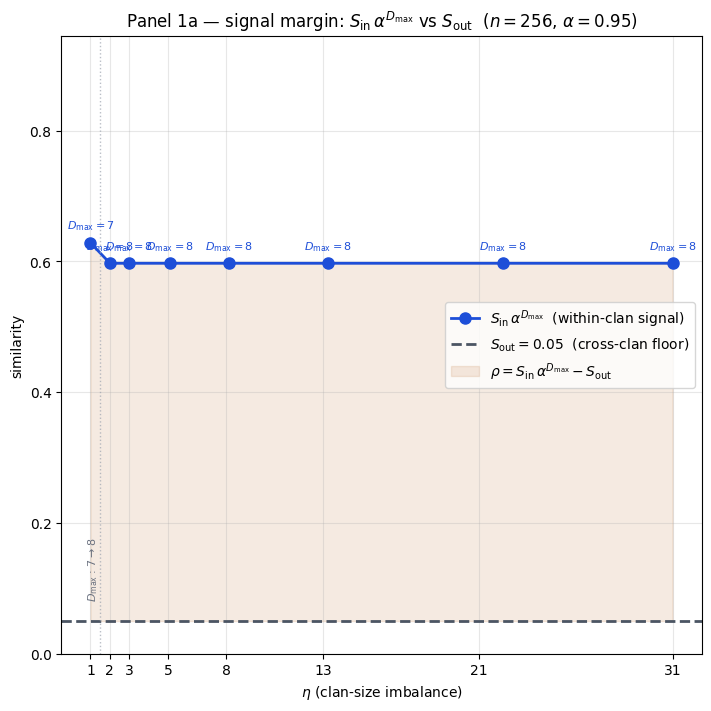

In [4]:
# Panel 1a — the within-clan decay factor alpha^{D_max} that drives rho.
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

# S_in * alpha^{D_max} (the signal-side ingredient) — descending step curve.
ax.plot(df["eta"], df["S_in_min"], "-o",
        color="#1d4ed8", lw=2, markersize=8,
        label=r"$S_{\mathrm{in}}\,\alpha^{D_{\max}}$  (within-clan signal)")
# S_out — constant noise floor.
ax.axhline(S_OUT, color="#4b5563", lw=2, ls="--",
           label=fr"$S_{{\mathrm{{out}}}} = {S_OUT}$  (cross-clan floor)")
# rho = vertical gap between the two — the structural margin.
ax.fill_between(df["eta"], df["S_in_min"], S_OUT,
                color="#b45309", alpha=0.12,
                label=r"$\rho = S_{\mathrm{in}}\,\alpha^{D_{\max}} - S_{\mathrm{out}}$")

# Annotate D_max value above each marker so the step is visible even when nearly flat.
for _, row in df.iterrows():
    ax.annotate(fr"$D_{{\max}}={int(row['D_max'])}$",
                xy=(row["eta"], row["S_in_min"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color="#1d4ed8")

# Mark the D_max step-down(s): light vertical line where ceil(log2(n_max)) increments.
d_arr = df["D_max"].values
e_arr = df["eta"].values
for k in np.where(np.diff(d_arr) > 0)[0]:
    e_step = 0.5 * (e_arr[k] + e_arr[k + 1])
    ax.axvline(e_step, color="#9ca3af", lw=1, ls=":", alpha=0.7)
    ax.text(e_step, S_OUT + 0.03,
            fr"$D_{{\max}}:\,{int(d_arr[k])}\to{int(d_arr[k+1])}$",
            rotation=90, va="bottom", ha="right", fontsize=8, color="#6b7280")

ax.set_xlabel(r"$\eta$ (clan-size imbalance)")
ax.set_ylabel(r"similarity")
ax.set_xticks(ETA_VALUES)
ax.set_ylim(0, max(df["S_in_min"].max(), S_IN) * 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="center right")
ax.set_title(
    fr"Panel 1a — signal margin: $S_{{\mathrm{{in}}}}\,\alpha^{{D_{{\max}}}}$ vs $S_{{\mathrm{{out}}}}$"
    fr"  ($n={N}$, $\alpha={ALPHA}$)",
    fontsize=12,
)
plt.show()

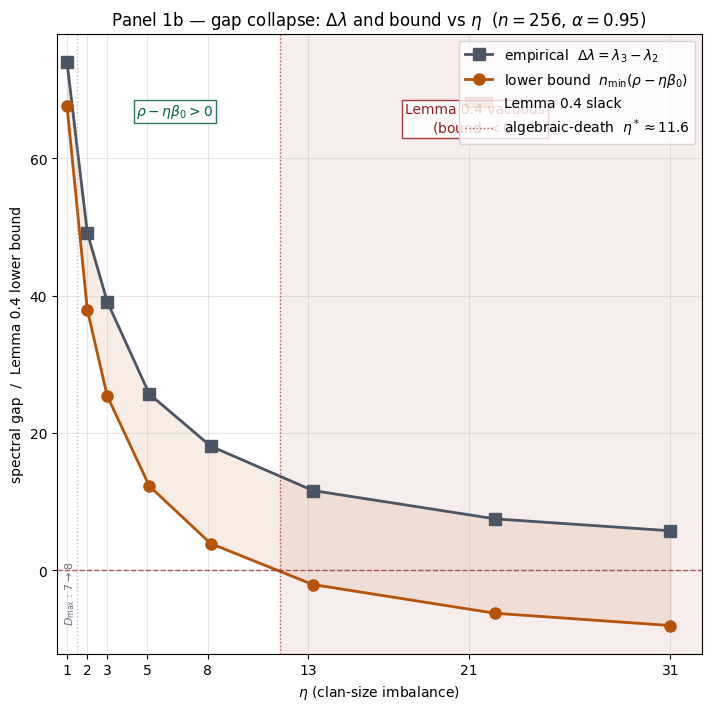

In [5]:
# Panel 1b — empirical gap vs Lemma-0.4 bound, with algebraic-death region.
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

# Shade the vacuous region (eta > eta*, where the lower bound is negative).
ax.axvspan(eta_star, max(ETA_VALUES) * 1.05,
           color="#991b1b", alpha=0.08, zorder=0)

ax.plot(df["eta"], df["gap_emp"], "-s",
        color="#4b5563", lw=2, markersize=8,
        label=r"empirical  $\Delta\lambda = \lambda_3 - \lambda_2$")
ax.plot(df["eta"], df["gap_lb"], "-o",
        color="#b45309", lw=2, markersize=8,
        label=r"lower bound  $n_{\min}(\rho - \eta\beta_0)$")
ax.fill_between(df["eta"], df["gap_lb"], df["gap_emp"],
                color="#b45309", alpha=0.10, label="Lemma 0.4 slack")
ax.axhline(0, color="#991b1b", lw=1, ls="--", alpha=0.7)
ax.axvline(eta_star, color="#991b1b", lw=1, ls=":", alpha=0.7,
           label=fr"algebraic-death  $\eta^* \approx {eta_star:.1f}$")

# Light annotations: name the two sides of eta*.
ymin, ymax = df["gap_lb"].min(), df["gap_emp"].max()
y_label = ymax * 0.92
ax.text(eta_star * 0.55, y_label, r"$\rho - \eta\beta_0 > 0$",
        ha="center", va="top", fontsize=10, color="#065f46",
        bbox=dict(facecolor="white", edgecolor="#065f46", alpha=0.85, pad=2))
ax.text((eta_star + max(ETA_VALUES)) / 2, y_label,
        "Lemma 0.4 vacuous\n(bound $<0$)",
        ha="center", va="top", fontsize=10, color="#991b1b",
        bbox=dict(facecolor="white", edgecolor="#991b1b", alpha=0.85, pad=2))

# D_max step-down marker (matches Panel 1a).
d_arr = df["D_max"].values
e_arr = df["eta"].values
for k in np.where(np.diff(d_arr) > 0)[0]:
    e_step = 0.5 * (e_arr[k] + e_arr[k + 1])
    ax.axvline(e_step, color="#9ca3af", lw=1, ls=":", alpha=0.7)
    ax.text(e_step, ymin, fr"$D_{{\max}}:\,{int(d_arr[k])}\to{int(d_arr[k+1])}$",
            rotation=90, va="bottom", ha="right", fontsize=8, color="#6b7280")

ax.set_xlabel(r"$\eta$ (clan-size imbalance)")
ax.set_ylabel(r"spectral gap  /  Lemma 0.4 lower bound")
ax.set_xticks(ETA_VALUES)
ax.set_xlim(0.5, max(ETA_VALUES) * 1.05)
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, steps=[1, 2, 5, 10]))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="upper right")
ax.set_title(
    fr"Panel 1b — gap collapse: $\Delta\lambda$ and bound vs $\eta$"
    fr"  ($n={N}$, $\alpha={ALPHA}$)",
    fontsize=12,
)
plt.show()

## Panel 2 — Statistical threat (noise amplification)

Closed-form curves, independent of sampling: $\mu_0(\eta) = (1+\eta)/2$ (coherence of the rank-2 subspace) and $\tilde{\rho}(\eta) = \frac{1+\eta}{2}\, S_{\mathrm{out}}^{2}$ (cross-clan variance load). Both inflate linearly with $\eta$ — the same uniform mask injects more noise into the smaller clan's Fiedler coordinates as imbalance grows.

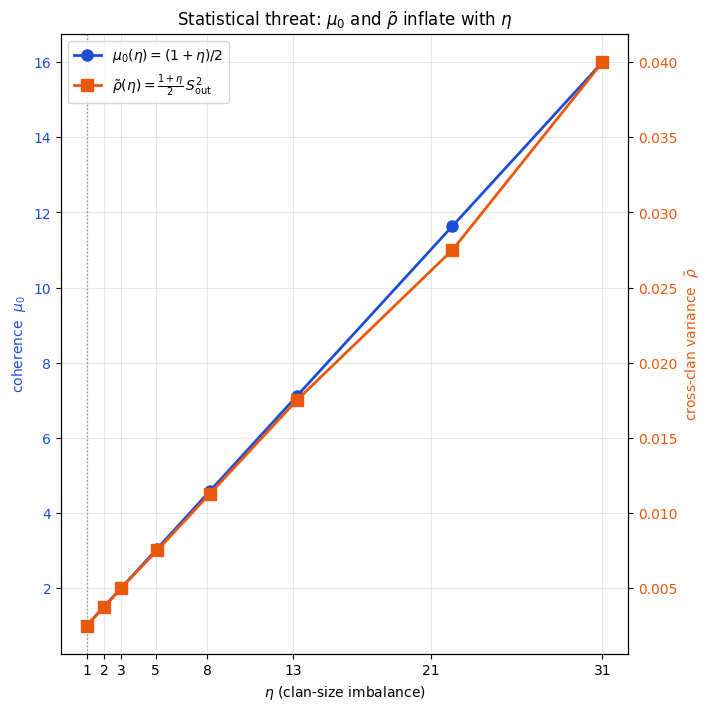

In [6]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax2 = ax.twinx()

l1, = ax.plot(df["eta"], df["mu_pred"], "-o",
              color="#1d4ed8", lw=2, markersize=8,
              label=r"$\mu_0(\eta) = (1+\eta)/2$")
l2, = ax2.plot(df["eta"], df["rho_tilde"], "-s",
               color="#ea580c", lw=2, markersize=8,
               label=r"$\tilde{\rho}(\eta) = \frac{1+\eta}{2}\, S_{\mathrm{out}}^{2}$")
ax.axvline(1, color="#4b5563", lw=1, ls=":", alpha=0.6)

ax.set_xlabel(r"$\eta$ (clan-size imbalance)")
ax.set_ylabel(r"coherence  $\mu_0$", color="#1d4ed8")
ax2.set_ylabel(r"cross-clan variance  $\tilde{\rho}$", color="#ea580c")
ax.tick_params(axis="y", labelcolor="#1d4ed8")
ax2.tick_params(axis="y", labelcolor="#ea580c")
ax.set_xticks(ETA_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(handles=[l1, l2], fontsize=10, loc="upper left")
ax.set_title(r"Statistical threat: $\mu_0$ and $\tilde{\rho}$ inflate with $\eta$",
             fontsize=12)
plt.show()

## Panel 3 — Compound failure (Monte-Carlo recovery)

For each $\eta$ we draw $B = 50$ uniform Bernoulli$(p)$ masks, apply IPW debiasing, compute the Fiedler vector, and measure sign-agreement against the population Fiedler. Mean recovery (with $\pm$ std band) is plotted at two fixed sampling rates $p \in \{0.15,\, 0.30\}$.

The fall-off is steeper than either threat alone would predict — the signal is shrinking *at the same time* as the noise is growing.

In [7]:
recovery_rows = []
for p in P_VALUES:
    for eta, (S, v_pop, n1, n2) in per_eta.items():
        accs = np.empty(N_BOOT)
        for b in range(N_BOOT):
            rng = np.random.default_rng(1000 * int(eta) + b)
            Omega = uniform_mask(N, p, rng)
            S_hat = ipw_from_mask(S, Omega, p)
            v_hat = compute_fiedler_of_S(S_hat, sampling_prob=p)
            accs[b] = compute_recovery(v_pop, v_hat)
        recovery_rows.append({
            "p": p, "eta": eta,
            "rec_mean": float(accs.mean()),
            "rec_std":  float(accs.std()),
        })
rec_df = pd.DataFrame(recovery_rows)
rec_df.pivot(index="eta", columns="p", values="rec_mean")

p,0.15,0.30
eta,,
1,1.000000,1.000000
2,1.000000,1.000000
3,1.000000,1.000000
5,0.994219,1.000000
8,0.977344,1.000000
13,0.945391,0.993125
21,0.956875,0.993437
31,0.963750,0.983359


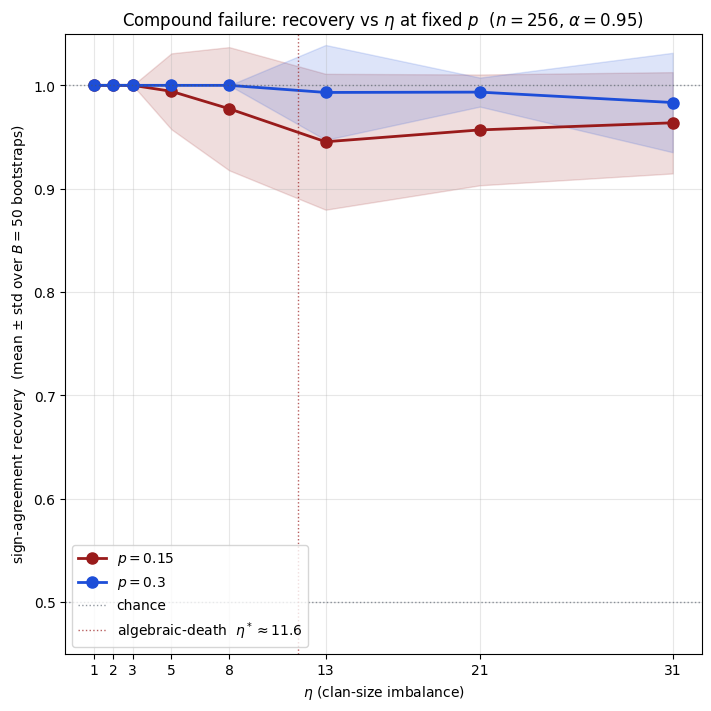

In [8]:
P_COLORS = {0.15: "#991b1b", 0.30: "#1d4ed8"}

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
for p in P_VALUES:
    sub = rec_df[rec_df["p"] == p].sort_values("eta")
    ax.plot(sub["eta"], sub["rec_mean"], "-o",
            color=P_COLORS[p], lw=2, markersize=8,
            label=fr"$p = {p}$")
    ax.fill_between(
        sub["eta"],
        sub["rec_mean"] - sub["rec_std"],
        sub["rec_mean"] + sub["rec_std"],
        color=P_COLORS[p], alpha=0.15,
    )
ax.axhline(0.5, color="#4b5563", lw=1, ls=":", alpha=0.6, label="chance")
ax.axhline(1.0, color="#4b5563", lw=1, ls=":", alpha=0.6)
ax.axvline(eta_star, color="#991b1b", lw=1, ls=":", alpha=0.7,
           label=fr"algebraic-death  $\eta^* \approx {eta_star:.1f}$")

ax.set_xlabel(r"$\eta$ (clan-size imbalance)")
ax.set_ylabel(r"sign-agreement recovery  (mean $\pm$ std over $B=50$ bootstraps)")
ax.set_xticks(ETA_VALUES)
ax.set_ylim(0.45, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="lower left")
ax.set_title(
    fr"Compound failure: recovery vs $\eta$ at fixed $p$  ($n={N}$, $\alpha={ALPHA}$)",
    fontsize=12,
)
plt.show()

## Takeaway

- **Panel 1** — the population spectral gap and its Lemma-0.4 lower bound both fall as $\eta$ grows. By $\eta \approx \rho/\beta_0$, the bound is exhausted: the true Fiedler split is gone before any sampling enters the picture.
- **Panel 2** — $\mu_0(\eta)$ and $\tilde{\rho}(\eta)$ inflate linearly with $\eta$. The same uniform $p$ injects more noise per small-clan coordinate.
- **Panel 3** — empirical recovery degrades faster than either threat alone would predict, because the signal is shrinking at the same time as the noise is growing. At low $p$ the compounding is severe; even moderate $p$ cannot save the split once $\eta$ approaches the algebraic-death threshold.